In [10]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import rdkit
import sys
import seaborn as sns
from rdkit import rdBase, Chem, DataStructs
from rdkit.Chem import AllChem, PandasTools
import pubchempy as pcp
from rdkit.Chem.Fraggle import FraggleSim

In [11]:
a_glu_df = pd.read_csv("../datasets/231113_a-glucosidase_dataset_all.csv", encoding='shift jis')
#kampo_df = pd.read_csv("../../kampo_db/kampo_data_original/230922/check/kampo_ESI_tateishi_240203_checked.csv", encoding='shift jis')
kampo_df = pd.read_csv("../ESI_3/virtual_screening_result/kampo_virtual_screening_ESI-3_top100_pIC50.csv", encoding='shift jis')

PandasTools.AddMoleculeColumnToFrame(a_glu_df,'Smiles','molecule',includeFingerprints=True)
PandasTools.AddMoleculeColumnToFrame(kampo_df,'smiles','molecule',includeFingerprints=True)# dfのmoleculeという列にMolオブジェクトを追加する。

a_glu_df

,comp_name,ChEMBL ID,Smiles,IC50(nM),IC50(M),pIC50,rUV,rex,rorb,rIR,...,1/dE22,1/dE23,1/dE24,1/dE25,1/dE26,1/dE27,1/dE28,1/dE29,1/dE30,molecule
0,comp_001,CHEMBL4576254,C=C(C)C(COc1c2ccoc2cc2oc(=O)ccc12)OC(C)(C)C(O)...,8800,0.0000,5.0555,35.3738,27.3813,92.3769,58.5249,...,0.1511,0.1499,0.1482,0.1478,0.1472,0.1471,0.1467,0.1459,0.1455,<rdkit.Chem.rdchem.Mol object at 0x7f7f11f42730>
1,comp_002,CHEMBL4516633,O=C(Cn1nnc2ccccc21)c1cccc(Cl)c1Cl,3470,0.0000,5.4597,9.4888,27.5001,90.2487,37.0927,...,0.1410,0.1378,0.1355,0.1346,0.1345,0.1338,0.1334,0.1324,0.1317,<rdkit.Chem.rdchem.Mol object at 0x7f7f11f42810>
2,comp_004,CHEMBL4453302,Cc1cccc2nc(-c3ccccc3Cl)[nH]c12,5300,0.0000,5.2757,14.2948,11.8939,89.8817,32.3868,...,0.1274,0.1257,0.1254,0.1232,0.1229,0.1227,0.1220,0.1218,0.1214,<rdkit.Chem.rdchem.Mol object at 0x7f7f11f428f0>
3,comp_005,CHEMBL4593597,O=C1NC(=O)/C(=C/c2ccc(-c3nc4ccccc4n3Cc3ccc(Cl)...,540,0.0000,6.2676,33.2624,39.0094,92.1613,53.8145,...,0.1577,0.1570,0.1562,0.1537,0.1532,0.1517,0.1509,0.1499,0.1490,<rdkit.Chem.rdchem.Mol object at 0x7f7f11f429d0>
4,comp_006,CHEMBL4460212,Clc1ccc(CSc2nc(-c3ccc(Br)cc3)cc(-c3ccc(Br)cc3)...,19000,0.0000,4.7212,52.1525,33.3409,87.6914,24.4834,...,0.1563,0.1559,0.1557,0.1552,0.1528,0.1525,0.1519,0.1511,0.1504,<rdkit.Chem.rdchem.Mol object at 0x7f7f11f42ab0>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
428,comp_568,CHEMBL3900431,O=C(Cn1cc(Cn2c(-c3ccc(F)cc3)nc(-c3ccccc3)c2-c2...,15000,0.0000,4.8239,41.0578,30.2186,94.2726,28.9944,...,0.1548,0.1542,0.1536,0.1530,0.1526,0.1509,0.1493,0.1493,0.1483,<rdkit.Chem.rdchem.Mol object at 0x7f7f11f66110>
429,comp_569,CHEMBL4458760,Cc1ccc(-c2cc(-c3cccc(Br)c3)nc(SCc3ccc(F)cc3)n2...,19000,0.0000,4.7212,47.8936,33.4961,91.6509,36.3355,...,0.1546,0.1543,0.1540,0.1526,0.1521,0.1512,0.1496,0.1481,0.1459,<rdkit.Chem.rdchem.Mol object at 0x7f7f11f661f0>
430,comp_570,CHEMBL4568608,Cc1ccc(-c2cc(-c3cccc(Br)c3)nc(SCc3cccc(F)c3)n2...,19000,0.0000,4.7212,47.7727,33.5077,92.3585,28.4074,...,0.1574,0.1540,0.1529,0.1527,0.1513,0.1504,0.1482,0.1463,0.1456,<rdkit.Chem.rdchem.Mol object at 0x7f7f11f662d0>
431,comp_572,CHEMBL4550622,Nc1nnc(-c2ccc([N+](=O)[O-])cc2)s1,2300,0.0000,5.6383,15.8358,23.6077,82.7969,32.8829,...,0.1345,0.1337,0.1323,0.1307,0.1295,0.1293,0.1271,0.1268,0.1265,<rdkit.Chem.rdchem.Mol object at 0x7f7f11f663b0>


In [12]:
kampo_df.head(2)

,number,pIC50(pred),cid,name,smiles,rex,rUV,rorb,rIR,rfreq,...,1/dE22,1/dE23,1/dE24,1/dE25,1/dE26,1/dE27,1/dE28,1/dE29,1/dE30,molecule
0,kampo_0400,6.4976,71448959,"2-[(1R,5R)-5-[2,4-Dihydroxy-3-(3-methylbut-2-e...",CC1=CC(CC(C1)(C2=C(C=C(C=C2)O)O)C(=O)C3=C(C(=C...,28.3821,18.7888,92.9141,36.8436,80.0312,...,0.1586,0.1585,0.1569,0.1561,0.1556,0.1524,0.1513,0.1511,0.1503,<rdkit.Chem.rdchem.Mol object at 0x7f7f11f66570>
1,kampo_1015,6.3075,101676953,CID 101676953,C1C(C(OC2=C1C(=C(C(=C2)O)C3C4C5C6C(COC(=O)C7=C...,86.8035,65.5046,93.0700,51.8402,78.1504,...,0.1928,0.1913,0.1893,0.1893,0.1890,0.1878,0.1854,0.1850,0.1838,<rdkit.Chem.rdchem.Mol object at 0x7f7f11f66650>


In [45]:
# Tanimoto coefficientを計算する。
a_glu_mol = a_glu_df.iloc[:,-1]
kampo_mol = kampo_df.iloc[:,-1]# Molオブジェクトのpd.Series
tanimotos = []

a_glu_morgan_fp = [AllChem.GetMorganFingerprintAsBitVect(amol, 2, 2048) for amol in a_glu_mol]
kampo_morgan_fp = [AllChem.GetMorganFingerprintAsBitVect(kmol, 2, 2048) for kmol in kampo_mol]

for i in range(a_glu_df.shape[0]):
    tanimoto = DataStructs.BulkTanimotoSimilarity(a_glu_morgan_fp[i], kampo_morgan_fp)
    #print(tanimoto)
    tanimotos.append(tanimoto)

df_sim = pd.DataFrame(tanimotos, index=a_glu_df['comp_name'], columns=kampo_df['number'])
pd.options.display.float_format = '{:.4f}'.format # 小数点を3桁に設定する。

df_sim.to_csv(f"tanimoto_similarity_a_glu_kampo_by_ESI-3.csv")
df_max = df_sim.max().to_frame('similarity_max')
kampo_ac = kampo_df.set_index("number").iloc[:,:4]
df_max = kampo_ac.join(df_max)
df_max.iloc[:50].to_csv(f"max_tanimoto_similarity_a_glu_kampo_by_ESI-3.csv", )
df_max.iloc[:50]

,pIC50(pred),cid,name,smiles,similarity_max
number,,,,,
kampo_0400,6.4976,71448959,"2-[(1R,5R)-5-[2,4-Dihydroxy-3-(3-methylbut-2-e...",CC1=CC(CC(C1)(C2=C(C=C(C=C2)O)O)C(=O)C3=C(C(=C...,0.2613
kampo_1015,6.3075,101676953,CID 101676953,C1C(C(OC2=C1C(=C(C(=C2)O)C3C4C5C6C(COC(=O)C7=C...,0.3867
kampo_2591,6.1649,73111,Sennoside A,C1=CC2=C(C(=C1)OC3C(C(C(C(O3)CO)O)O)O)C(=O)C4=...,0.2500
kampo_1963,6.0987,5318993,Licoagrone,CC(=CCC1=CC2=C(C=C1O)OC(C2=O)(C3=CC(=C(C=C3C=C...,0.2842
kampo_0547,6.0445,6440013,4-Coumaroyl-CoA,CC(C)(COP(=O)(O)OP(=O)(O)OCC1C(C(C(O1)N2C=NC3=...,0.1739
kampo_2332,5.9910,5320384,Palmidin A,CC1=CC2=C(C(=C1)O)C(=O)C3=C(C2C4C5=C(C(=CC=C5)...,0.2222
kampo_1179,5.9837,73644,Casuarictin,C1C2C(C3C(C(O2)OC(=O)C4=CC(=C(C(=C4)O)O)O)OC(=...,0.1932
kampo_0759,5.9301,467312,"8-((5,7-Dihydroxy-2-(3,4,5-trihydroxyphenyl)-3...",C1C(C(OC2=C1C(=CC(=C2CC3=C(C=C(C4=C3OC(C(C4)OC...,0.2500
kampo_1123,5.9288,6119622,Caffeoyl-coenzyme A,CC(C)(COP(=O)(O)OP(=O)(O)OCC1C(C(C(O1)N2C=NC3=...,0.1739


In [30]:
df_max.to_frame('sim')

,sim
number,
kampo_0400,0.2613
kampo_1015,0.3867
kampo_2591,0.2500
kampo_1963,0.2842
kampo_0547,0.1739
...,...
kampo_2777,0.2462
kampo_1778,0.3913
kampo_2404,0.3725


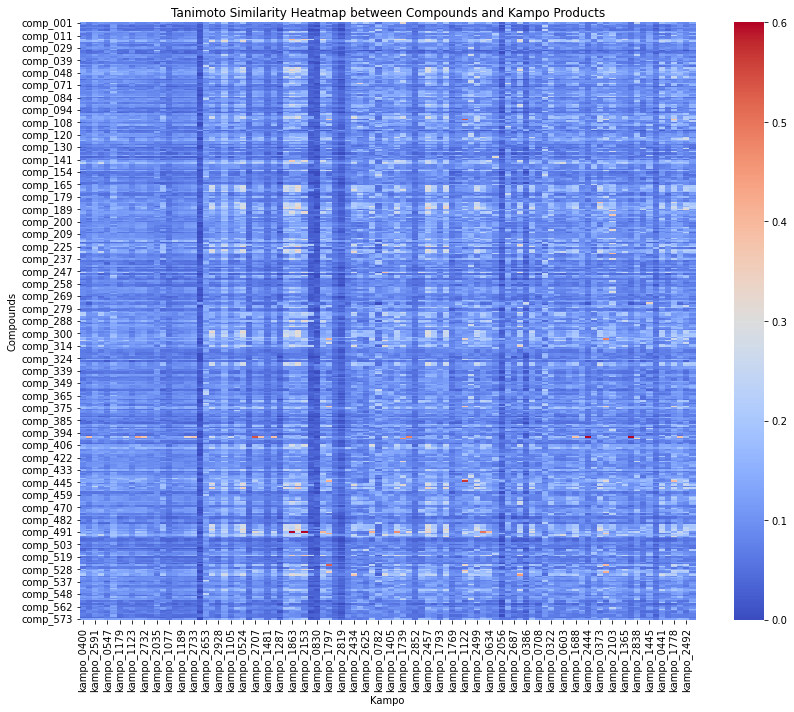

In [5]:
plt.figure(figsize=(12, 10))

# Creating the heatmap
#sns.heatmap(df_sim, cmap="YlGnBu")
sns.heatmap(df_sim, cmap="coolwarm",vmax=0.6, vmin=0.0)
plt.title('Tanimoto Similarity Heatmap between Compounds and Kampo Products')
plt.xlabel('Kampo')
plt.ylabel('Compounds')

# Displaying the heatmap
plt.tight_layout() # Adjusts plot to ensure everything fits without overlap
plt.show()

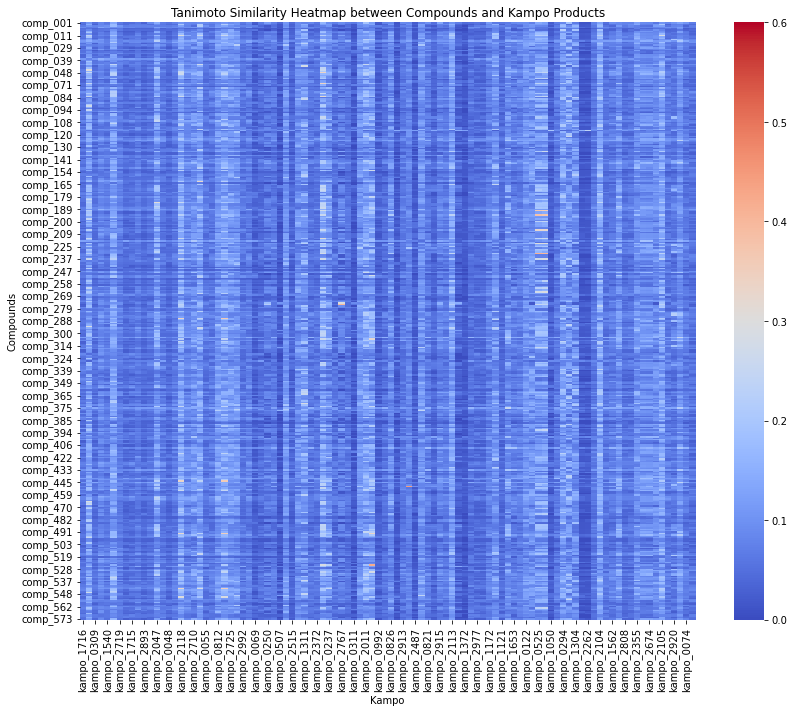

In [6]:
a_glu_df = pd.read_csv("../datasets/231113_a-glucosidase_dataset_all.csv", encoding='shift jis')
kampo_df = pd.read_csv("../summury/kampo_virtual_screening_ECFP4_top100_pIC50.csv", encoding='shift jis')
PandasTools.AddMoleculeColumnToFrame(a_glu_df,'Smiles','molecule',includeFingerprints=True)
PandasTools.AddMoleculeColumnToFrame(kampo_df,'smiles','molecule',includeFingerprints=True)# dfのmoleculeという列にMolオブジェクトを追加する。

# Tanimoto coefficientを計算する。
a_glu_mol = a_glu_df.iloc[:,-1]
kampo_mol = kampo_df.iloc[:,-1]# Molオブジェクトのpd.Series
tanimotos = []

a_glu_morgan_fp = [AllChem.GetMorganFingerprintAsBitVect(amol, 2, 2048) for amol in a_glu_mol]
kampo_morgan_fp = [AllChem.GetMorganFingerprintAsBitVect(kmol, 2, 2048) for kmol in kampo_mol]

for i in range(a_glu_df.shape[0]):
    tanimoto = DataStructs.BulkTanimotoSimilarity(a_glu_morgan_fp[i], kampo_morgan_fp)
    #print(tanimoto)
    tanimotos.append(tanimoto)

df_sim = pd.DataFrame(tanimotos, index=a_glu_df['comp_name'], columns=kampo_df['number'])
pd.options.display.float_format = '{:.4f}'.format # 小数点を3桁に設定する。

df_sim.to_csv(f"tanimoto_similarity_a_glu_kampo_by_ECFP4.csv")
#print(df_sim)

plt.figure(figsize=(12, 10))

# Creating the heatmap
sns.heatmap(df_sim,cmap="coolwarm",vmax=0.6 ,vmin=0.0)
plt.title('Tanimoto Similarity Heatmap between Compounds and Kampo Products')
plt.xlabel('Kampo')
plt.ylabel('Compounds')

# Displaying the heatmap
plt.tight_layout() # Adjusts plot to ensure everything fits without overlap
plt.show()

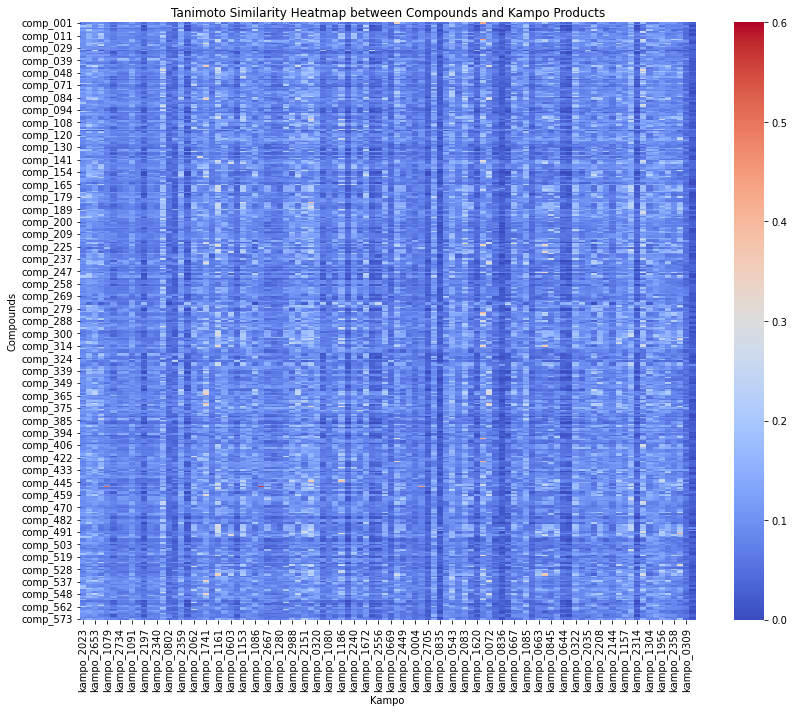

In [7]:
a_glu_df = pd.read_csv("../datasets/231113_a-glucosidase_dataset_all.csv", encoding='shift jis')
kampo_df = pd.read_csv("../summury/kampo_virtual_screening_rdkit_top100_pIC50.csv", encoding='shift jis')
PandasTools.AddMoleculeColumnToFrame(a_glu_df,'Smiles','molecule',includeFingerprints=True)
PandasTools.AddMoleculeColumnToFrame(kampo_df,'smiles','molecule',includeFingerprints=True)# dfのmoleculeという列にMolオブジェクトを追加する。

# Tanimoto coefficientを計算する。
a_glu_mol = a_glu_df.iloc[:,-1]
kampo_mol = kampo_df.iloc[:,-1]# Molオブジェクトのpd.Series
tanimotos = []

a_glu_morgan_fp = [AllChem.GetMorganFingerprintAsBitVect(amol, 2, 2048) for amol in a_glu_mol]
kampo_morgan_fp = [AllChem.GetMorganFingerprintAsBitVect(kmol, 2, 2048) for kmol in kampo_mol]

for i in range(a_glu_df.shape[0]):
    tanimoto = DataStructs.BulkTanimotoSimilarity(a_glu_morgan_fp[i], kampo_morgan_fp)
    #print(tanimoto)
    tanimotos.append(tanimoto)

df_sim = pd.DataFrame(tanimotos, index=a_glu_df['comp_name'], columns=kampo_df['number'])
pd.options.display.float_format = '{:.4f}'.format # 小数点を3桁に設定する。

df_sim.to_csv(f"tanimoto_similarity_a_glu_kampo_by_rdkit.csv")
#print(df_sim)

plt.figure(figsize=(12, 10))

# Creating the heatmap
sns.heatmap(df_sim, cmap="coolwarm",vmax=0.6 ,vmin=0.0)
plt.title('Tanimoto Similarity Heatmap between Compounds and Kampo Products')
plt.xlabel('Kampo')
plt.ylabel('Compounds')

# Displaying the heatmap
plt.tight_layout() # Adjusts plot to ensure everything fits without overlap
plt.show()